# **I. Introduction**

---
## Background
The energy market has undergone massive transformation—new players in the market have increased competition, new pricing models have given customers more flexibility, and a shift toward renewable energy have forced legacy utility companies to invest in new technologies. With more energy providers offering flexible rates, clean energy alternatives, and digital-first customer experiences, PowerCo has been losing customers to their competitors at a higher-than-average rate, eating into margins and threatening long-term growth. The objective of this program gives recommendation action for handling potential churn customers.

---
## Data Background
Data is collected from Boston Consulting Grup (BCG) client with some data masking without changing the meaning of the data
![Deskripsi Data](dataset_description.jpg)

# **II. Libraries Preparation**

In [ ]:
# Import Packages
import pandas as pd
import numpy as np
import sklearn
import shap
import dill                                                                                                                                          
import sweetviz as sv  
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import FunctionTransformer, PowerTransformer, TargetEncoder, StandardScaler, QuantileTransformer
from sklearn.compose import ColumnTransformer                              
from sklearn.pipeline import make_pipeline                        
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score    
from feature_engine.outliers import Winsorizer                                                                       
from pycaret.classification import *                                                                                                                  
from imblearn.pipeline import make_pipeline as imbl_make_pipeline
from xgboost import XGBClassifier
from sklearn import set_config as sk_set_config

# **III. Initial Exploratory Data Analysis (First EDA)**
---
## a. Load Data

In [57]:
# Load Data
client_df = pd.read_csv('client_data.csv') 
client_df

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2023-06-15,2026-06-15,2025-11-01,2025-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2019-08-21,2026-08-30,2019-08-21,2025-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2020-04-16,2026-04-16,2020-04-16,2025-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2020-03-30,2026-03-30,2020-03-30,2025-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2020-01-13,2026-03-07,2020-01-13,2025-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2022-05-24,2026-05-08,2025-05-08,2024-05-26,4648.01,...,t,0.00,27.88,27.88,2,381.77,4,lxidpiddsbxsbosboudacockeimpuepw,15.000,0
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2022-08-27,2026-08-27,2022-08-27,2025-08-28,631.69,...,f,15.94,0.00,0.00,1,90.34,3,lxidpiddsbxsbosboudacockeimpuepw,6.000,1
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2022-02-08,2026-02-07,2022-02-08,2025-02-09,190.39,...,f,18.05,39.84,39.84,1,20.38,4,lxidpiddsbxsbosboudacockeimpuepw,15.935,1
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2022-08-30,2026-08-30,2022-08-30,2025-08-31,19.34,...,f,0.00,13.08,13.08,1,0.96,3,lxidpiddsbxsbosboudacockeimpuepw,11.000,0


In [58]:
# Load Data
price_df = pd.read_csv('price_data.csv')
price_df

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2025-01-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
1,038af19179925da21a25619c5a24b745,2025-02-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
2,038af19179925da21a25619c5a24b745,2025-03-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
3,038af19179925da21a25619c5a24b745,2025-04-01,0.149626,0.000000,0.000000,44.266931,0.00000,0.000000
4,038af19179925da21a25619c5a24b745,2025-05-01,0.149626,0.000000,0.000000,44.266931,0.00000,0.000000
...,...,...,...,...,...,...,...,...
192997,16f51cdc2baa19af0b940ee1b3dd17d5,2025-08-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192998,16f51cdc2baa19af0b940ee1b3dd17d5,2025-09-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192999,16f51cdc2baa19af0b940ee1b3dd17d5,2025-10-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
193000,16f51cdc2baa19af0b940ee1b3dd17d5,2025-11-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555


---
## b. Data Overview

In [59]:
# Check Data Type and Missing Value
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

**Comment**
- There are date-based features using inappropriate data type
- Data is clean from standard missing value
- There are 3 categorical columns, namely, "channel_sales", "has_gas" and "origin_up"

In [60]:
# Check Duplicate Row
print(f"Duplicate Rows: {client_df.duplicated().sum()}")

# Check Duplicate ID
print(f"Duplicate ID: {client_df.duplicated(subset=['id']).sum()}")

Duplicate Rows: 0
Duplicate ID: 0


**Comment**
- There is no duplicate row
- There is no duplicate ID

In [61]:
# Check Data Type and Missing Value
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [62]:
# Check Duplicated Row
print(f"Duplicated Rows: {price_df.duplicated().sum()}")

# Check Duplicate ID
print(f"Duplicated ID: {price_df.duplicated(subset=['id']).sum()}")

Duplicated Rows: 0
Duplicated ID: 176906


In [63]:
# Further Check of Duplicate ID
counts_per_id = price_df['id'].value_counts()
avg_frequency = counts_per_id.mean()
print(f"Average Each ID: {avg_frequency}")

Average Each ID: 11.990680914512922


**Comment**
- There is no duplicate row
- There are duplicate ID averaging on 12, it will be a note and need further exploration why this happens

In [64]:
# Data Aggregation Overview
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


**Comment**

There is a indication, "cons_gas_12m", "forecast_cons_year" and "nb_prod_act" have low variation dan most of data are just on one value. "cons_gas_12m" and "has_gas" are indicated high correlated and there is possibility to drop one of them.

In [65]:
# Data Aggregation Overview
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


**Comment**
- There is no numerical column with negative value
- It seems, based on ratio of Mean and Median, most of features are skew

---
## c. Data Exploration

In [66]:
# Back Up Data
client_eda_1 = client_df.copy()
price_eda_1 = price_df.copy()

### Non Standard Missing Value Check

In [67]:
# Change Date-based Data Types for 'client_data'
cols_to_fix = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
client_eda_1[cols_to_fix] = client_eda_1[cols_to_fix].apply(pd.to_datetime, errors='coerce')

# Change Date-based Data Types for 'price_data'
price_eda_1['price_date'] = pd.to_datetime(price_eda_1['price_date'], errors='coerce')

In [68]:
# Check Null After Transform Data Type
print(client_eda_1[cols_to_fix].isnull().sum())
print(f"price_date: {price_eda_1['price_date'].isnull().sum()}")

date_activ         0
date_end           0
date_modif_prod    0
date_renewal       0
dtype: int64
price_date: 0


In [69]:
# Check Date-based Features Consistency
# Check Date Range
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
start_date = pd.to_datetime('2013-01-01')
end_date = pd.to_datetime('2028-12-31')
within_range = client_eda_1[date_cols].apply(lambda x: x.between(start_date, end_date)).all(axis=1)

# Check "date_activ" as the earliest (except "date_modif_prod" can be earlier 60 days)
activ_is_earliest = (
    (client_eda_1['date_activ'] <= client_eda_1['date_end']) &
    (client_eda_1['date_activ'] - pd.Timedelta(days=60) <= client_eda_1['date_modif_prod']) &
    (client_eda_1['date_activ'] <= client_eda_1['date_renewal']))

# Check "date_end" as the latest
end_is_latest = (
    (client_eda_1['date_end'] >= client_eda_1['date_activ']) &
    (client_eda_1['date_end'] >= client_eda_1['date_modif_prod']) &
    (client_eda_1['date_end'] >= client_eda_1['date_renewal']))

# Check "date_modif_prod" and "date_renewal" ranging from "date_activ" to "date_end" (except "date_modif_prod" can be earlier 60 days)
is_logical_sequence = (
    (client_eda_1['date_modif_prod'] >= (client_eda_1['date_activ'] - pd.Timedelta(days=60))) & 
    (client_eda_1['date_modif_prod'] <= client_eda_1['date_end']) &
    (client_eda_1['date_renewal'] >= client_eda_1['date_activ']) & 
    (client_eda_1['date_renewal'] <= client_eda_1['date_end']))

# Check Summary
client_eda_1['is_date_valid'] = within_range & activ_is_earliest & end_is_latest & is_logical_sequence
print(f"Total Row: {len(client_eda_1)}")
print(f"Total Row of Valid Date: {client_eda_1['is_date_valid'].sum()}")

Total Row: 14606
Total Row of Valid Date: 14606


In [70]:
# Check Whether Data Range is on year of 2025
price_eda_1['price_date'].describe()

count                           193002
mean     2025-06-16 12:50:49.933161472
min                2025-01-01 00:00:00
25%                2025-04-01 00:00:00
50%                2025-07-01 00:00:00
75%                2025-10-01 00:00:00
max                2025-12-01 00:00:00
Name: price_date, dtype: object

**Comment**
- On the date-based features, there is no standard missing value
- Date-based features need date type transformation
- Based on Average Number of ID and Date Range on price_date, it can be conclude that duplication of ID happens every months within 1 year. Therefore, we should aggregate this data so that we could extract valuable information

In [71]:
# Check Unique Value
cols_to_explore = [col for col in client_eda_1.select_dtypes(include=['object']).columns if col != 'id']
count_data = []
for col in cols_to_explore:
    counts = client_eda_1[col].value_counts(dropna=False)
    for val, count in counts.items():
        count_data.append({
            'Column Name': col,
            'Unique Value': val,
            'Count': count})

count_df = pd.DataFrame(count_data)
count_df

,Column Name,Unique Value,Count
0,channel_sales,foosdfpfkusacimwkcsosbicdxkicaua,6754
1,channel_sales,MISSING,3725
2,channel_sales,lmkebamcaaclubfxadlmueccxoimlema,1843
3,channel_sales,usilxuppasemubllopkaafesmlibmsdf,1375
4,channel_sales,ewpakwlliwisiwduibdlfmalxowmwpci,893
5,channel_sales,sddiedcslfslkckwlfkdpoeeailfpeds,11
6,channel_sales,epumfxlbckeskwekxbiuasklxalciiuu,3
7,channel_sales,fixdbufsefwooaasfcxdxadsiekoceaa,2
8,has_gas,f,11955
9,has_gas,t,2651


**Comment**
- Since the data was modified for company security, we should define every unique values for better interpretation
- For "channel_sales", there are considerable amount of MISSING, identified as missing values. Therefore, we will transform it become Undefined Channel
- For every categories with the number of total below than 1 % of whole data, we regroup them as "Others" icluding "MISSING" in "origin_up"

### Data Distribution

In [72]:
# Interactive EDA
report = sv.analyze(client_df)
report.show_html('EDA_client_df.html')

                                             |          | [  0%]   00:00 -> (? left)

Report EDA_client_df.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


**Comment**

There are some notes we found on the interactive EDA, namely,
1. 'forecast_price_energy_peak' contains many zero, if we want to keep it, we have to see the differences od peak and off-peak price. Futhermore, there are anomaly between peak and off-peak price, the data was swapped
2. 'margin_gross_pow_ele' and 'margin_net_pow_ele' are totally same
3. 'forecast_cons_year' is more represented by 'forecast_cons_12m'
4. 'num_year_antig' is more represented by month-based generated on price_df

In [73]:
# Correct Column Name
cols_correct = {
    'forecast_price_energy_peak': 'forecast_price_energy_off_peak',
    'forecast_price_energy_off_peak': 'forecast_price_energy_peak'}

client_df = client_df.rename(columns=cols_correct)

In [74]:
# Explore 'forecast_price_energy_peak'
anomaly_check = client_df['forecast_price_energy_peak'] < client_df['forecast_price_energy_off_peak']
anomaly_num = anomaly_check.sum()
print(f'Number of Anomaly : {anomaly_num}')
client_df[['forecast_price_energy_peak', 'forecast_price_energy_off_peak']].sort_values(by='forecast_price_energy_off_peak').tail(5)

Number of Anomaly : 0


,forecast_price_energy_peak,forecast_price_energy_off_peak
1912,0.245347,0.168092
7196,0.245347,0.168092
3749,0.245347,0.168092
4493,0.245347,0.168092
4541,0.245926,0.195975


In [75]:
# Interactive EDA
report = sv.analyze(price_df)
report.show_html('EDA_price_df.html')

                                             |          | [  0%]   00:00 -> (? left)

Report EDA_price_df.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


**Comment**

From the distribution, we can see the data is row. We need to calculate the difference of each season to get valuable information. However, the data is not clean. There are many zero value and almost zero value on off-peak as baseline. Subsequently, Off-peak price should be the lowest followed by mid and peak price.

Finding the problem on peak and off-peak on client_data, after further exploration, the anomaly also happen on price_df, so that we have to transform those.

In [76]:
# Correct Column Names
cols_correct = {
    'price_off_peak_var': 'price_peak_var',
    'price_peak_var': 'price_mid_peak_var',
    'price_mid_peak_var': 'price_off_peak_var', 
    'price_off_peak_fix': 'price_peak_fix',
    'price_peak_fix': 'price_mid_peak_fix',
    'price_mid_peak_fix': 'price_off_peak_fix'}

price_df = price_df.rename(columns=cols_correct)
price_df.sort_values(by='price_off_peak_var')

,id,price_date,price_peak_var,price_mid_peak_var,price_off_peak_var,price_peak_fix,price_mid_peak_fix,price_off_peak_fix
0,038af19179925da21a25619c5a24b745,2025-01-01,0.151367,0.000000,0.000000,44.266931,0.000000,0.000000
111035,7590deb8871805e433f52e8acfc0225e,2025-06-01,0.153048,0.000000,0.000000,44.444710,0.000000,0.000000
111034,7590deb8871805e433f52e8acfc0225e,2025-05-01,0.153048,0.000000,0.000000,44.444710,0.000000,0.000000
111033,7590deb8871805e433f52e8acfc0225e,2025-04-01,0.153048,0.000000,0.000000,44.444710,0.000000,0.000000
111032,7590deb8871805e433f52e8acfc0225e,2025-03-01,0.153739,0.000000,0.000000,44.444710,0.000000,0.000000
...,...,...,...,...,...,...,...,...
473,33bb3af90650ac2e9ecac6ff2c975a6b,2025-06-01,0.160327,0.137606,0.104202,41.063969,24.837586,16.724391
474,33bb3af90650ac2e9ecac6ff2c975a6b,2025-07-01,0.160327,0.137606,0.104202,41.063969,24.837586,16.724391
469,33bb3af90650ac2e9ecac6ff2c975a6b,2025-02-01,0.207221,0.168256,0.114102,41.063970,24.837581,16.724389
468,33bb3af90650ac2e9ecac6ff2c975a6b,2025-01-01,0.207221,0.168256,0.114102,41.063970,24.837581,16.724389


In [77]:
# Clean Data from Wrong Input (Off-Peak is our baseline, so that it is never close to 0)
price_df = price_df.drop(price_df[price_df['price_off_peak_var'] < 0.01].index)
price_df = price_df.drop(price_df[price_df['price_off_peak_fix'] < 0.01].index)

In [78]:
# Explore Anomaly of Seasonality Price
def get_invalid_mask(df, tipe):
    off = df[f'price_off_peak_{tipe}']
    mid = df[f'price_mid_peak_{tipe}']
    peak = df[f'price_peak_{tipe}']
    
    cond_1 = (off > 0) & (mid > 0) & (off >= mid)
    cond_2 = (mid > 0) & (peak > 0) & (mid >= peak)
    cond_3 = (off > 0) & (peak > 0) & (off >= peak)

    return cond_1 | cond_2 | cond_3

invalid_var = get_invalid_mask(price_df, 'var')
invalid_fix = get_invalid_mask(price_df, 'fix')

anomaly = invalid_var | invalid_fix
anomaly_df = price_df[anomaly]
anomaly_df

,id,price_date,price_peak_var,price_mid_peak_var,price_off_peak_var,price_peak_fix,price_mid_peak_fix,price_off_peak_fix
71515,b95b613fb2530dbfc00b9225e1a232fc,2025-01-01,0.108401,0.095838,0.069362,58.936774,0.095556,8.334260
71516,b95b613fb2530dbfc00b9225e1a232fc,2025-02-01,0.108401,0.095838,0.069362,58.936774,0.095556,8.334260
164650,c6951b289531272a5d02c095db1fb55f,2025-01-01,0.108254,0.096908,0.095375,58.936774,0.069113,8.334260
164651,c6951b289531272a5d02c095db1fb55f,2025-02-01,0.108254,0.096908,0.095375,58.936774,0.069113,8.334260
164652,c6951b289531272a5d02c095db1fb55f,2025-03-01,0.108254,0.096908,0.095375,58.936780,0.069113,8.334263


In [79]:
# Drop Anomaly Rows
index_anomali = anomaly_df.index
price_df = price_df.drop(index_anomali).reset_index(drop=True)

---
## d. Data Condition

1. Data Type
    - There are date-based features using unsuitable data type.
2. Standard Missing Value
    - Data is clear from standard missing value
3. Duplicate Data
    - Data is clear from duplicate data
4. Non Standard Missing Value
    - There are non-standard missing values with some handling needed

# **IV. Feature Engineering**

---
## a. Initial Engineering

In [80]:
# Check Data
print(f"Total Customer on Client Dataset {client_df['id'].nunique()}")
print(f"Total Customer on Price Dataset {price_df['id'].nunique()}")

Total Customer on Client Dataset 14606
Total Customer on Price Dataset 6764


In [81]:
# Find Intersection between both data
common_ids = set(client_df['id']) & set(price_df['id'])

# Synchronize both data
client_df = client_df[client_df['id'].isin(common_ids)].reset_index(drop=True)
price_df = price_df[price_df['id'].isin(common_ids)].reset_index(drop=True)
price_df.to_csv('deployment/clean_price_data.csv', index=False)

# Intergration Data
print(f"Total Customer on Client Dataset: {client_df['id'].nunique()}")
print(f"Total Customer on Price Dataset: {price_df['id'].nunique()}")

Total Customer on Client Dataset: 5644
Total Customer on Price Dataset: 5644


In [82]:
# Initial Feature Engineering
def feature_engineering (X):
    X['cons_last_ratio']=X['cons_last_month']/(X['cons_12m']/12)
    X['forecast_price_energy_diff']=X['forecast_price_energy_peak']-X['forecast_price_energy_off_peak']
    X=X.drop(columns=['cons_last_month', 'forecast_cons_year', 'margin_gross_pow_ele', 'num_years_antig', 'forecast_price_energy_peak', 'forecast_price_energy_off_peak', 'has_gas'])
    return X

feature_trans = FunctionTransformer(feature_engineering)

**Code Background**

Since the price data is monthly report, we should find how to extract the information.
There are 3 different price of each season, namely: **Peak, Mid-Peak, Off-Peak** of **Power and Energy Price**.

Regarding the data, we will transform data with steps below,
1. The price should be groupped by ID to summarize 12 months price become one price. Grouping will be generated by 'Mean" and "Max"
2. To understand the sensitivity of price, we should extract the difference price of seasons, namely, Off-Peak with Mid Peak and Off-Peak with Peak

In [83]:
# Price Transformation
def add_price_features(X, price_df):
    types = ['var', 'fix']
    agg_dict = {}

    for t in types:
        off_col = f'price_off_peak_{t}'
        mid_col = f'price_mid_peak_{t}'
        peak_col = f'price_peak_{t}'
        
        mid_diff_key = f'mid_off_{t}_diff'
        peak_diff_key = f'peak_off_{t}_diff'
        
        price_df[mid_diff_key] = np.where(price_df[mid_col] > 0, 
                                            price_df[mid_col] - price_df[off_col], 0)
        
        price_df[peak_diff_key] = np.where(price_df[peak_col] > 0, 
                                             price_df[peak_col] - price_df[off_col], 0)

        agg_dict[mid_diff_key] = ['mean', 'max']
        agg_dict[peak_diff_key] = ['mean', 'max']

    grouped_prices = price_df.groupby('id').agg(agg_dict)

    grouped_prices.columns = [f"{stat}_{col}" for col, stat in grouped_prices.columns]
    grouped_prices = grouped_prices.reset_index()

    X = pd.merge(X, grouped_prices, on='id', how='left')

    numeric_cols = X.select_dtypes(include=['number']).columns
    X[numeric_cols] = X[numeric_cols].fillna(0)

    return X

price_feature_transformer = FunctionTransformer(
    add_price_features, 
    kw_args={'price_df': price_df})

---
## b. Categorical Transformation

**Code Background**

Categorical transformation will be based on decision of previous EDA

In [84]:
# Categorical Transformation
def transform_categorical_features(X):
    channel_mapping = {
        'foosdfpfkusacimwkcsosbicdxkicaua': 'Direct Sales',
        'usilxuppasemubllopkaafesmlibmsdf': 'International Broker',
        'lmkebamcaaclubfxadlmueccxoimlema': 'Local Broker',
        'ewpakwlliwisiwduibdlfmalxowmwpci': 'Government Tender',
        'epumfxlbckeskwekxbiuasklxalciiuu': 'Other Channels',
        'fixdbufsefwooaasfcxdxadsiekoceaa': 'Other Channels',
        'sddiedcslfslkckwlfkdpoeeailfpeds': 'Other Channels',
        'MISSING': 'Untracked Channel'
    }
    X['channel_sales'] = X['channel_sales'].replace(channel_mapping)
    
    origin_mapping = {
        'kamkkxfxxuwbdslkwifmmcsiusiuosws': 'Special Offers',
        'lxidpiddsbxsbosboudacockeimpuepw': 'Seasonal Offers',
        'ldkssxwpmemidmecebumciepifcamkci': 'Referral',
        'MISSING': 'Untracked Origin',
        'usapbepcfoloekilkwsdiboslwaxobdp': 'Other Origins',
        'ewxeelcelemmiwuafmddpobolfuxioce': 'Other Origins'
    }
    X['origin_up'] = X['origin_up'].replace(origin_mapping)
    
    return X

categorical_trans = FunctionTransformer(transform_categorical_features)

---
## c. Date-based Features' Transformation

**Code Background**

Since this project isn't use time-series analysis, we should extract information from all date-based features. We will the total amount of each date-based column referenced with 1 January 2026


In [85]:
# Data Type Transformation
def transform_date_features(X):
    date_columns = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
    ref_date = datetime(2026, 1, 1)
    
    for col in date_columns:
        dates = pd.to_datetime(X[col], format='%Y-%m-%d')
        
        year_diff = ref_date.year - dates.dt.year
        month_diff = ref_date.month - dates.dt.month
        months = year_diff * 12 + month_diff
        months -= (ref_date.day < dates.dt.day).astype(int)
        
        if col == 'date_activ':
            X['months_activ'] = months
        elif col == 'date_end':
            X['months_to_end'] = -months
        elif col == 'date_modif_prod':
            X['months_modif_prod'] = months
        elif col == 'date_renewal':
            X['months_renewal'] = months
            
    remove = [
        'date_activ', 
        'date_end', 
        'date_modif_prod', 
        'date_renewal',
        'id']
    
    X = X.drop(columns=remove)
    return X

date_trans = FunctionTransformer(transform_date_features)

---
## d. Exploratory Data Analysis (Second EDA)

In [86]:
# EDA Dataset Preparation
second_eda = feature_engineering(client_df)
second_eda = add_price_features(second_eda, price_df)
second_eda = transform_categorical_features(second_eda)
second_eda = transform_date_features(second_eda)

# Interactive EDA
report = sv.analyze(second_eda)
report.show_html('EDA_transformed.html')

                                             |          | [  0%]   00:00 -> (? left)

Report EDA_transformed.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


**Comment**

Some feature's distribution looks skew. We will ensure then by calculating skewness value

In [87]:
# Check Skew Values
num_cols = list(second_eda.select_dtypes(exclude='object').columns)
list_item= []
for col in num_cols:
    skew_val = round(second_eda[col].skew(), 1)
    if abs(skew_val) <= 0.5:
        label = 'normal'
    else:
        label = 'skewed'
    list_item.append([col, skew_val, label])

pd.DataFrame(columns=['Columns', 'Skew Value', 'Distribution'], data= list_item)

,Columns,Skew Value,Distribution
0,cons_12m,5.5,skewed
1,cons_gas_12m,9.3,skewed
2,forecast_cons_12m,7.4,skewed
3,forecast_discount_energy,5.1,skewed
4,forecast_meter_rent_12m,3.0,skewed
5,forecast_price_pow_off_peak,4.0,skewed
6,imp_cons,14.3,skewed
7,margin_net_pow_ele,3.0,skewed
8,nb_prod_act,4.1,skewed
9,net_margin,32.2,skewed


---
## e. Features Transformation

### Transforming Categorical Data (Encoding)

In [88]:
# Feature engineering for nominal columns
nom_cols = ['channel_sales', 'origin_up']
nom_pipe = TargetEncoder(smooth="auto", random_state=40)

### Transforming Numerical Data (Capping and Scaling)

**Code Background**

There are 4 treatments for numerical columns, namely:
1. Transformation without capping, yeo-johnson transformer and standard scaling subsequently, because of low variation,
2. Transformation with three-fold iqr's capping, yeo-johnson transformer and standard scaling subsequently.
3. Transformation for normal skew features with only standard scaling

In [89]:
# Feature engineering for numerical columns
skew_cols = ['cons_12m',
            'forecast_cons_12m', 
            'forecast_meter_rent_12m', 
            'imp_cons', 
            'margin_net_pow_ele', 
            'net_margin', 
            'pow_max', 
            'cons_last_ratio', 
            'forecast_price_energy_diff', 
            'mean_mid_off_var_diff', 
            'max_mid_off_var_diff', 
            'mean_peak_off_var_diff',
            'mean_mid_off_fix_diff', 
            'max_peak_off_var_diff', 
            'mean_peak_off_fix_diff', 
            'months_activ', 
            'months_modif_prod']

skew_no_cap_cols=['cons_gas_12m',
                  'forecast_discount_energy',
                  'forecast_price_pow_off_peak',
                  'nb_prod_act',
                  'max_mid_off_fix_diff',
                  'max_peak_off_fix_diff']

norm_cols = ['months_to_end', 
            'months_renewal']

med_skew_num = make_pipeline(Winsorizer(capping_method='iqr',                       
                                        tail='both',
                                        fold=3,
                                        missing_values='ignore'),
                                        PowerTransformer(method='yeo-johnson'),
                            StandardScaler()) 

skew_no_cap = make_pipeline(QuantileTransformer(output_distribution='normal',
                                                random_state=40),
                            StandardScaler())

norm_skew_num = StandardScaler()

# Transformation Pipeline
preprocessor = ColumnTransformer([
    ('nom_encoding', nom_pipe, nom_cols),
    ('skew', med_skew_num, skew_cols),
    ('skew_no_cap', skew_no_cap, skew_no_cap_cols),
    ('norm_skew', norm_skew_num, norm_cols)])

**Comment**

After transformation, there are better skewness on numerical columns. Although forecast_discount_energy is still high, we keep this skew because it is pivotal to know impacts of discount.

---
## f. Exploratory Data Analysis (Third EDA)

In [90]:
# Data Check Preparation
X_third_eda = client_df.drop(['churn'], axis = 1)
y_third_eda = client_df['churn']  
sk_set_config(transform_output="pandas")

pipe_third_eda = imbl_make_pipeline(feature_trans,
                                    price_feature_transformer, 
                                    categorical_trans, 
                                    date_trans,
                                    preprocessor)

# Transform Features
pipe_third_eda.fit(X_third_eda, y_third_eda)
X_third_eda_trans = pipe_third_eda.transform(X_third_eda)
features_third_eda = X_third_eda_trans.columns.tolist()

# CHeck Skew After Transformation
X_third_eda_trans.skew().sort_values(ascending=False)

skew_no_cap__forecast_discount_energy       5.297095
skew_no_cap__forecast_price_pow_off_peak    3.378120
skew_no_cap__max_mid_off_fix_diff           2.067008
skew__mean_peak_off_fix_diff                1.873040
skew__mean_mid_off_fix_diff                 1.823462
skew_no_cap__max_peak_off_fix_diff          1.770833
skew_no_cap__cons_gas_12m                   1.469467
skew_no_cap__nb_prod_act                    1.239203
norm_skew__months_renewal                   0.449495
skew__forecast_meter_rent_12m               0.142728
skew__cons_12m                              0.044671
norm_skew__months_to_end                    0.037502
skew__months_activ                          0.020980
skew__cons_last_ratio                       0.010592
skew__forecast_price_energy_diff            0.004268
skew__mean_peak_off_var_diff               -0.011658
skew__mean_mid_off_var_diff                -0.019859
skew__margin_net_pow_ele                   -0.039435
skew__forecast_cons_12m                    -0.

In [91]:
# Data Preparation
sklearn.set_config(transform_output="default")
X_MI_df = pd.DataFrame(X_third_eda_trans, columns=features_third_eda)

# Calculate Mutual Information
mi_scores = mutual_info_classif(X_MI_df, y_third_eda, random_state=40)
mi_results = pd.Series(mi_scores, index=features_third_eda).sort_values(ascending=False)
mi_df = pd.DataFrame({
    'Feature': features_third_eda,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False).reset_index(drop=True)

print("Mutual Information Score:")
mi_df

Mutual Information Score:


,Feature,MI Score
0,skew__cons_last_ratio,0.018240
1,skew__margin_net_pow_ele,0.014239
2,skew__forecast_meter_rent_12m,0.013798
3,skew__months_modif_prod,0.011890
4,skew__months_activ,0.010303
5,norm_skew__months_renewal,0.010104
6,skew__mean_peak_off_var_diff,0.009424
7,skew__mean_mid_off_var_diff,0.007835
8,skew__cons_12m,0.006376
9,nom_encoding__channel_sales,0.006292


---
## g. Dataset Preparation for Modelling

In [92]:
# Train, Validation, Test Splitting
X = client_df.drop(['churn'], axis = 1)
y = client_df['churn']  

# Splitting Train and Test Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

# Splitting for Inference Simulation
X_test, X_inf, y_test, y_inf = train_test_split(X_test, y_test, test_size=0.01, random_state=40)
X_inf.to_csv('deployment/inference_data.csv', index=False)

In [93]:
# Interactive EDA
train_full = pd.concat([X_train, y_train], axis=1)
test_full = pd.concat([X_test, y_test], axis=1)

report = sv.compare(
    [train_full, "Training Data"], 
    [test_full, "Test Data"], 
    target_feat='churn')

report.show_html('EDA_train_test.html')

                                             |          | [  0%]   00:00 -> (? left)

Report EDA_train_test.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


# **V. Model Comparison**

In [94]:
# Model Comparison
clf_setup = setup(
    data = X_third_eda_trans, 
    target = y_third_eda, 
    session_id = 40,
    normalize = False,
    transformation = False,
    fix_imbalance = True,
    ignore_features = ['id'])

best_model = compare_models()

,Description,Value
0,Session id,40
1,Target,churn
2,Target type,Binary
3,Original data shape,"(5644, 28)"
4,Transformed data shape,"(8692, 28)"
5,Transformed train set shape,"(6998, 28)"
6,Transformed test set shape,"(1694, 28)"
7,Ignore features,1
8,Numeric features,27
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.8858,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0470
xgboost,Extreme Gradient Boosting,0.8825,0.6781,0.1972,0.4821,0.2771,0.2248,0.2532,0.8190
et,Extra Trees Classifier,0.8813,0.6652,0.1486,0.4449,0.2202,0.1735,0.2052,0.5580
lightgbm,Light Gradient Boosting Machine,0.8775,0.6758,0.1662,0.4240,0.2353,0.1821,0.2074,0.5270
rf,Random Forest Classifier,0.8770,0.6598,0.1353,0.4190,0.2003,0.1509,0.1820,1.1730
gbc,Gradient Boosting Classifier,0.8410,0.6544,0.1973,0.2553,0.2212,0.1345,0.1366,2.2950
dt,Decision Tree Classifier,0.7823,0.5545,0.2594,0.1807,0.2120,0.0906,0.0931,0.1210
ada,Ada Boost Classifier,0.7562,0.6156,0.3035,0.1725,0.2192,0.0874,0.0930,0.7030
knn,K Neighbors Classifier,0.6671,0.5856,0.3946,0.1463,0.2133,0.0560,0.0669,0.0640
lr,Logistic Regression,0.6390,0.6589,0.6054,0.1796,0.2767,0.1223,0.1628,1.6250


# **VI. Model Training**

In [96]:
# Pipeline Preparation
xgb = imbl_make_pipeline(feature_trans, price_feature_transformer, categorical_trans, date_trans, preprocessor, XGBClassifier(scale_pos_weight=6, max_depth=2))

# Train Data
xgb.fit(X_train, y_train)

Pipeline(memory=None,
         steps=[('functiontransformer-1',
                 FunctionTransformer(accept_sparse=False, check_inverse=True,
                                     feature_names_out=None,
                                     func=<function feature_engineering at 0x000001A928ACEA60>,
                                     inv_kw_args=None, inverse_func=None,
                                     kw_args=None, validate=False)),
                ('functiontransformer-2',
                 FunctionTransformer(accept_sparse=False, check_inverse=True,
                                     feature_nam...
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='binary:logistic', ...))],
         verbose=False)

In [97]:
xgb.steps[-1][1]

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='binary:logistic', ...)

# **VII. Model Evaluation**

Train
              precision    recall  f1-score   support

           0       0.95      0.84      0.90      3987
           1       0.37      0.69      0.48       528

    accuracy                           0.83      4515
   macro avg       0.66      0.77      0.69      4515
weighted avg       0.88      0.83      0.85      4515


Test
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      1003
           1       0.20      0.45      0.28       114

    accuracy                           0.76      1117
   macro avg       0.56      0.62      0.57      1117
weighted avg       0.85      0.76      0.80      1117


Confusion Matrix


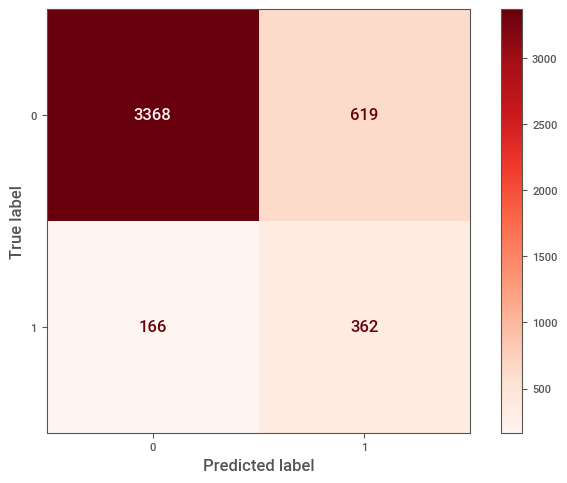

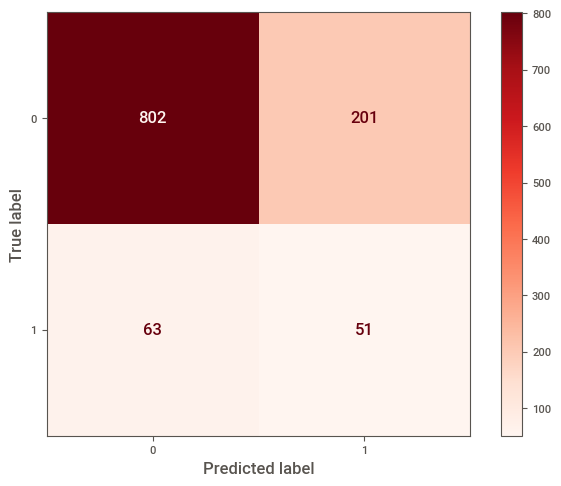

In [98]:
# Checking The Best Model Performance
y_pred_train = xgb.predict(X_train)
y_pred_test = xgb.predict(X_test)

print('Train')
print(classification_report(y_train, y_pred_train))
print()
print('Test')
print(classification_report(y_test, y_pred_test))
print()
print('Confusion Matrix')
print(ConfusionMatrixDisplay.from_estimator(xgb, X_train, y_train, cmap='Reds'))
print(ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test, cmap='Reds'))

AUC Score :  0.6659757569397072


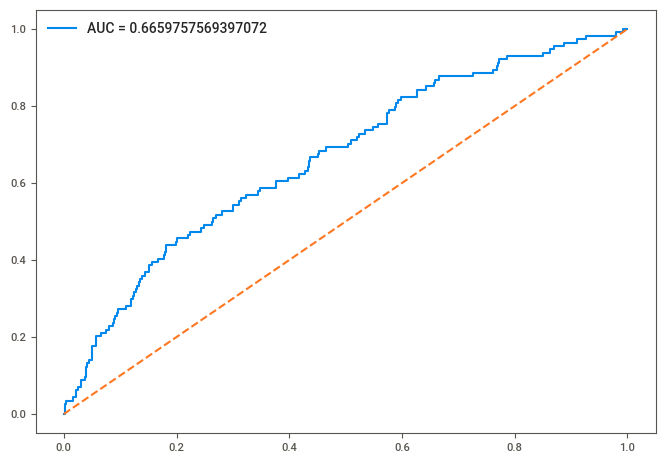

In [99]:
# Calculating AUC
y_pred_final = xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_final)
auc = roc_auc_score(y_test, y_pred_final)
print('AUC Score : ', auc)

# Visualizing ROC-AUC Curve
plt.figure(0).clf()
plt.plot(fpr, tpr, label='AUC = ' + str(auc))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend(loc=0)

**Comment**

The model is unreliable for predicting churn in the future with high confidence. However, for churn risk management, this model still could alert the sympthom of churn customer

# **VIII. Model Saving**

In [100]:
# Saving Model
with open('deployment/final_model.pkl', 'wb') as a:
    dill.dump(xgb, a)

# **IX. Model Interpretation**

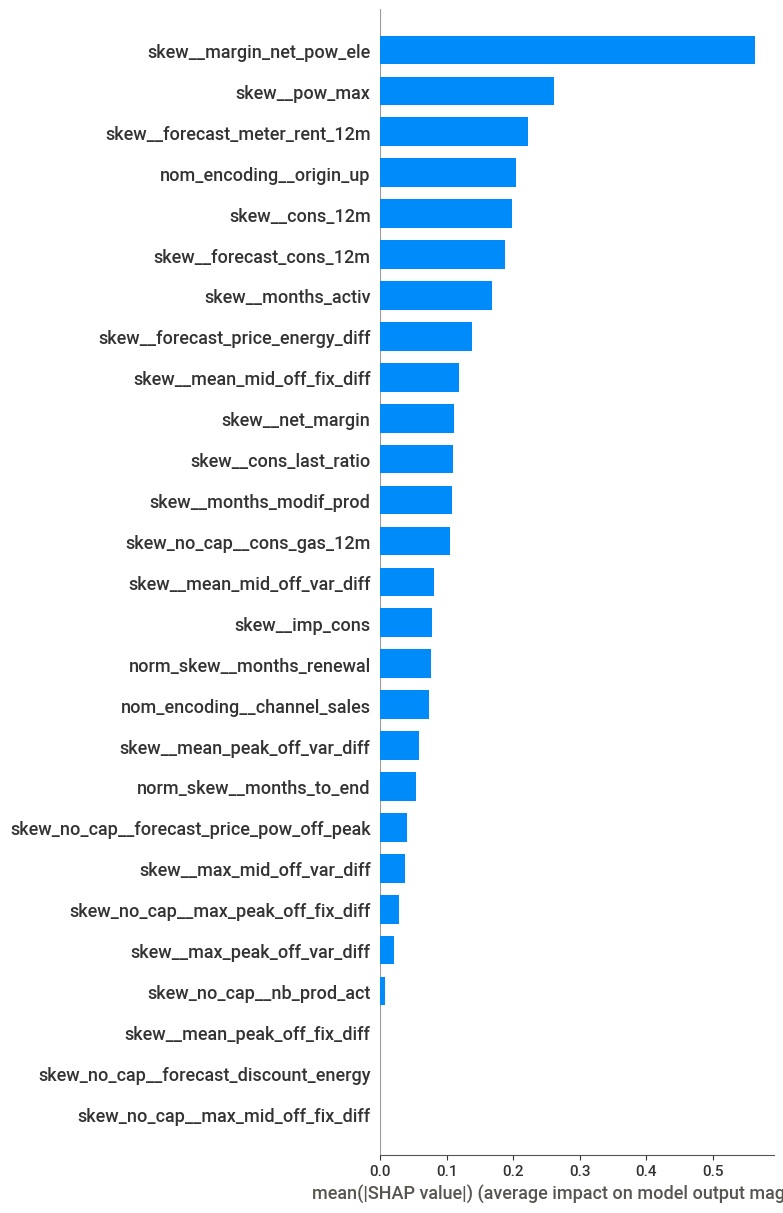

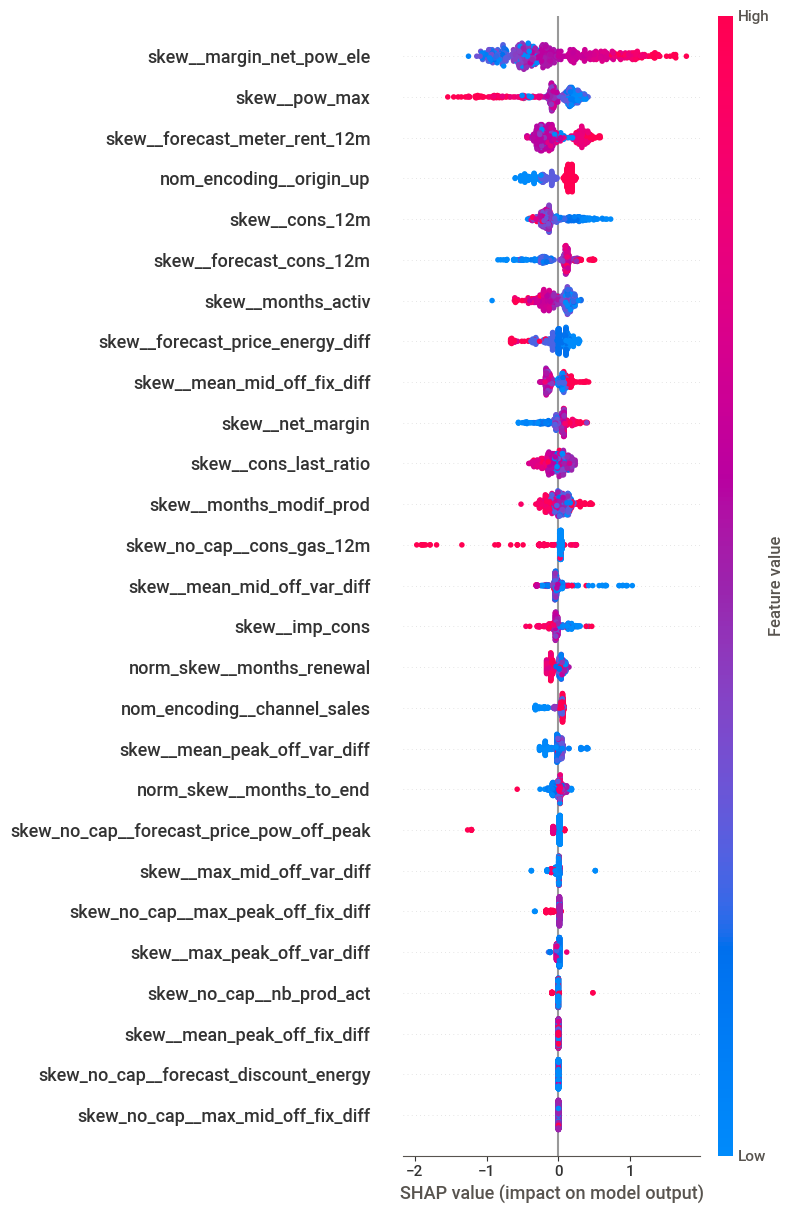

SHAP Importance Values:
                                     feature  mean_abs_shap
6                   skew__margin_net_pow_ele       0.563711
8                              skew__pow_max       0.261529
4              skew__forecast_meter_rent_12m       0.221351
1                    nom_encoding__origin_up       0.204116
2                             skew__cons_12m       0.198576
3                    skew__forecast_cons_12m       0.187257
17                        skew__months_activ       0.168541
10          skew__forecast_price_energy_diff       0.137746
14               skew__mean_mid_off_fix_diff       0.118349
7                           skew__net_margin       0.110879
9                      skew__cons_last_ratio       0.109786
18                   skew__months_modif_prod       0.108330
19                 skew_no_cap__cons_gas_12m       0.104032
11               skew__mean_mid_off_var_diff       0.081190
5                             skew__imp_cons       0.078248
26              

In [101]:
# Output Setting
sklearn.set_config(transform_output="pandas")

# Model Extraction
xgb_model = xgb.named_steps['xgbclassifier']

# Extract Features
X_temp = xgb[:-1].transform(X_train)
feature_names = X_temp.columns.tolist()

# Sampling
X_val_df = X_temp
sample_size = min(500, len(X_val_df))
X_sample = X_val_df.sample(n=sample_size, random_state=10)

# SHAP Explainer
explainer = shap.TreeExplainer(xgb_model)
shap_results = explainer.shap_values(X_sample)

if isinstance(shap_results, list):
    shap_values_to_plot = shap_results[1]
else:
    shap_values_to_plot = shap_results

# Visualization
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_sample, plot_type="bar", max_display=50)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_sample, max_display=50)

shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values_to_plot).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("SHAP Importance Values:")
print(shap_importance.head(50))

dependence plot untuk melihat apakah semua yang marginnya tinggi akan churn atau yang berasal dari Direct sales yang lebih banyak akan churn? jadi bisa lebih segmented strateginya. Kalau sebelumnya harus intervensi 100 orang, ini bisa cuma intervensi 20 orang yang channel salesnya direct sales

<Figure size 1000x600 with 0 Axes>

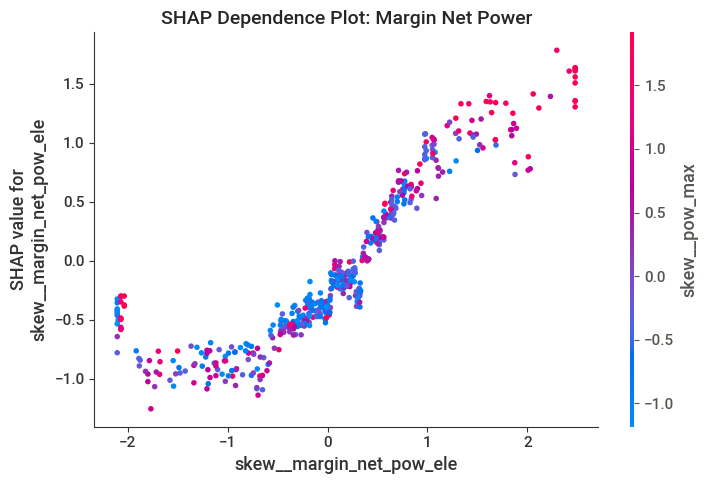

In [102]:
# Net Margin Dependence Plot (Aplikasikan untuk beberapa variabel" yang kuat).
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "skew__margin_net_pow_ele", 
    shap_values_to_plot, 
    X_sample, 
    interaction_index="skew__pow_max", 
    show=False
)
plt.title("SHAP Dependence Plot: Margin Net Power", fontsize=14)
plt.tight_layout()
plt.show()

# **X. Recommendation Action**

In [103]:
# Extract Probability Values
y_prob_test = xgb.predict_proba(X_test)[:, 1]
eval_df = pd.DataFrame({
    'Actual_Churn': y_test,
    'Churn_Probability': y_prob_test})

In [104]:
# Data Preparation
profiling_df = X_test.copy()
profiling_df = add_price_features(profiling_df, price_df)
profiling_df = transform_categorical_features(profiling_df)
profiling_df = transform_date_features(profiling_df)

# Merge Data
profiling_df['Churn_Probability'] = eval_df['Churn_Probability'].values
profiling_df['Actual_Churn'] = eval_df['Actual_Churn'].values

In [105]:
# Determine Deciles
profiling_df['Churn Decile'] = pd.qcut(profiling_df['Churn_Probability'], q=10, labels=False, duplicates='drop')
profiling_df['Churn Decile'] = profiling_df['Churn Decile'].max() - profiling_df['Churn Decile'] + 1
profiling_df[['Churn_Probability', 'Churn Decile']].head()

,Churn_Probability,Churn Decile
0,0.448516,3
1,0.582621,2
2,0.292705,7
3,0.185829,9
4,0.351806,5


In [106]:
# Analyze Decile
decile_analysis = profiling_df.groupby('Churn Decile').agg(
    Total_Customers=('Actual_Churn', 'count'),
    Actual_Churners=('Actual_Churn', 'sum'),
    Min_Probability=('Churn_Probability', 'min'),
    Max_Probability=('Churn_Probability', 'max')
).reset_index()

# Calculate Churn Rate
decile_analysis['Churn_Rate'] = decile_analysis['Actual_Churners'] / decile_analysis['Total_Customers']
decile_analysis['Churn_Rate'] = decile_analysis['Churn_Rate'].apply(lambda x: f"{x:.2%}")

# Show Data
decile_analysis = decile_analysis.sort_values(by='Churn Decile').reset_index(drop=True)
decile_analysis

,Churn Decile,Total_Customers,Actual_Churners,Min_Probability,Max_Probability,Churn_Rate
0,1,112,26,0.615074,0.934093,23.21%
1,2,112,20,0.530025,0.613306,17.86%
2,3,111,13,0.446138,0.529954,11.71%
3,4,112,10,0.391331,0.444927,8.93%
4,5,111,10,0.338626,0.390598,9.01%
5,6,112,11,0.294937,0.338522,9.82%
6,7,112,10,0.250994,0.294638,8.93%
7,8,111,5,0.204021,0.250975,4.50%
8,9,112,5,0.138080,0.203956,4.46%
9,10,112,4,0.008794,0.137466,3.57%


In [107]:
# Group Based on Customer Value
q_labels = ['Low', 'Lower-Mid', 'Upper-Mid', 'High']
profiling_df['Customer Value Quantiles'] = pd.qcut(profiling_df['net_margin'], q=4, labels=q_labels)

# Customer Value Quantiles' Summary
value_analysis = profiling_df.groupby('Customer Value Quantiles').agg(
    Total_Customers=('Actual_Churn', 'count'),
    Actual_Churners=('Actual_Churn', 'sum'),
    Mean_Margin=('net_margin', 'mean'),
    Min_Margin=('net_margin', 'min'),
    Max_Margin=('net_margin', 'max')
).reset_index()

# Calculate Churn Rate
value_analysis['Churn_Rate'] = value_analysis['Actual_Churners'] / value_analysis['Total_Customers']
value_analysis['Churn_Rate'] = value_analysis['Churn_Rate'].apply(lambda x: f"{x:.2%}")
display(value_analysis)

,Customer Value Quantiles,Total_Customers,Actual_Churners,Mean_Margin,Min_Margin,Max_Margin,Churn_Rate
0,Low,280,27,47.189750,0.00,94.50,9.64%
1,Lower-Mid,279,26,149.030681,94.55,214.02,9.32%
2,Upper-Mid,279,28,302.196846,214.38,423.83,10.04%
3,High,279,33,652.705125,425.04,10203.50,11.83%


In [108]:
# Customer Distribution
matrix = pd.crosstab(profiling_df['Customer Value Quantiles'], profiling_df['Churn Decile'])
matrix

Churn Decile,1,2,3,4,5,6,7,8,9,10
Customer Value Quantiles,,,,,,,,,,
Low,29,37,22,27,36,35,19,25,13,37
Lower-Mid,27,26,36,35,26,26,30,30,31,12
Upper-Mid,25,22,31,29,28,26,33,25,33,27
High,31,27,22,21,21,25,30,31,35,36


In [109]:
# Determine Intervention Actions
def intervention_actions (row):
    decile = row['Churn Decile']
    value_segment = row['Customer Value Quantiles']
    
    # High Risk
    if decile <= 7: # High Risk until Decile 4 because our budget threshold percentage for each customer is 30%
        if value_segment == 'High':
            return "1 - Personalized Intervention"
        else:
            return "3 - Business as Usual"

    # Low Risk
    elif decile >= 9:
        if value_segment == 'High':
            return "2 - Special Loyalty Program"
        else:
            return "3 - Business as Usual"

    # Mid Risk
    else:
        return "3 - Business as Usual"

profiling_df['Recommedation Action'] = profiling_df.apply(intervention_actions, axis=1)

In [110]:
# Action SUmmary
action_summary = profiling_df.groupby('Recommedation Action').agg(
    Total_Customer=('Actual_Churn', 'count'),
    Actual_Churners=('Actual_Churn', 'sum'),
    Avg_Net_Margin=('net_margin', 'mean')
).reset_index()

# Calculate Average Net Margin
action_summary['Avg_Net_Margin']=action_summary['Avg_Net_Margin']*1000

# Calculate Churn Rate
action_summary['Churn Rate (%)'] = (action_summary['Actual_Churners'] / action_summary['Total_Customer']) * 100

# Clobal Churn Rate
global_churn = action_summary['Total_Customer'].sum()
action_summary['Global Churn Rate (%)'] = (action_summary['Actual_Churners'] / global_churn) * 100

# Calculate Intervention Cost
def get_unit_cost(action):
    if '1 - Personalized' in action:
        return 10000 # Churn Rate Handling by $50 per customer
    elif '2 - Special Loyalty' in action:
        return 1000 # Long-Term Investment for Valuable with Low Churn Rate Customer
    else:
        return

action_summary['Unit_Cost ($)'] = action_summary['Recommedation Action'].apply(get_unit_cost)

# Total Cost
action_summary['Total_Cost ($)'] = action_summary['Total_Customer'] * action_summary['Unit_Cost ($)']

# Revenue Saved
action_summary['Profit_Saved ($)'] = action_summary['Actual_Churners'] * action_summary['Avg_Net_Margin']

# Net Profit
action_summary['Net_Profit ($)'] = action_summary['Profit_Saved ($)'] - action_summary['Total_Cost ($)']

# Invervention Cost Allocation
action_summary['Cost per Saved Revenue (%)'] = np.where(
    action_summary['Total_Cost ($)'] > 0,
    (action_summary['Total_Cost ($)'] / action_summary['Profit_Saved ($)']) * 100, 0)

# Set Format
action_summary['Churn Rate (%)'] = action_summary['Churn Rate (%)'].apply(lambda x: f"{x:.2f}%")
action_summary['Global Churn Rate (%)'] = action_summary['Global Churn Rate (%)'].apply(lambda x: f"{x:.2f}%")
action_summary['Avg_Net_Margin'] = action_summary['Avg_Net_Margin'].apply(lambda x: f"${x:,.2f}")
action_summary['Total_Cost ($)'] = action_summary['Total_Cost ($)'].apply(lambda x: f"${x:,.2f}")
action_summary['Profit_Saved ($)'] = action_summary['Profit_Saved ($)'].apply(lambda x: f"${x:,.2f}")
action_summary['Net_Profit ($)'] = action_summary['Net_Profit ($)'].apply(lambda x: f"${x:,.2f}")
action_summary['Cost per Saved Revenue (%)'] = action_summary['Cost per Saved Revenue (%)'].apply(lambda x: f"{x:,.2f}%" if x != 0 else "N/A")

# Show Data
action_summary = action_summary.sort_values(by='Recommedation Action').reset_index(drop=True)
action_summary

,Recommedation Action,Total_Customer,Actual_Churners,Avg_Net_Margin,Churn Rate (%),Global Churn Rate (%),Unit_Cost ($),Total_Cost ($),Profit_Saved ($),Net_Profit ($),Cost per Saved Revenue (%)
0,1 - Personalized Intervention,177,30,"$703,342.88",16.95%,2.69%,10000.0,"$1,770,000.00","$21,100,286.44","$19,330,286.44",8.39%
1,2 - Special Loyalty Program,71,3,"$563,068.17",4.23%,0.27%,1000.0,"$71,000.00","$1,689,204.51","$1,618,204.51",4.20%
2,3 - Business as Usual,869,81,"$180,369.17",9.32%,7.25%,NaN,$nan,"$14,609,902.89",$nan,N/A
